In [1]:
# Window
from IPython.display import display, HTML
display(HTML("<style>.container { width:90% !important; }</style>"))
display(HTML("<style>.output_result { width:90% !important; }</style>"))

<div class="alert alert-block alert-danger">
These notebooks are better visualized using codefolding from Jupyter
    <a href=\"https://jupyter-contrib-nbextensions.readthedocs.io/en/latest/\">extensions</a>.
</div>

In [1]:
# Basic everyday packages
import time
import numpy  as np
import matplotlib.pyplot as plt
plt.style.use('ggplot')

In [2]:
# Single function imports
from scipy.integrate import quad, dblquad

# Integral when intersection is a disc

$\newcommand{\dif}{\,\mathrm{d}}$
We are interested in computing the following integral:
\begin{align*}
    G(x) = \int\limits_{ x - B(x;\varepsilon) } K(y) \,\mathrm{d}y,
\end{align*}
where $ K(r) = \frac{1}{2\pi} \log |r| $, and we assume that $x \in B(0;1-\varepsilon)$. Notice that in such case, we have that $x - B(x;\varepsilon) = B(0;\varepsilon)$, and thus the function $G$ is constant in this region. Thus, let's compute
\begin{align*}
    g = \int\limits_{ B(0;\varepsilon) } K(y) \,\mathrm{d}y.
\end{align*}
Let us introduce polar coordinates centred at the origin, which are handy to parametrise the domain. Then we have that
\begin{align*}
    g = \frac{1}{2\pi} \int\limits_0^{2\pi} \int\limits_{0}^\varepsilon  r \log(r)  \,\mathrm{d}r \,\mathrm{d}\theta = \frac{\varepsilon^2}{4}(\log \varepsilon^2 - 1).
\end{align*}


In [3]:
def integral_numeric(ε, ep=1e-12):
    """
    Numerically approximates g(ε) = 1/(2π) ∫_0^ε ∫_0^2π s log(s) dθ ds
    """
    f = lambda θ, s: s * np.log(s) * 0.5 / np.pi
    return dblquad(f, 0, ε, 0, 2*np.pi, epsabs = ep, epsrel = ep)[0]

def integral_closed(ε):
    """
    Closed-form value: 2π log((u + √(ε² − v²))/2)
    """
    return 0.25 * ε**2.0 * (np.log(ε**2) - 1.0)

In [4]:
integral_numeric(1.0, ep=1e-14), integral_closed(1.0)

(-0.24999999999999992, np.float64(-0.25))

In [5]:
A = np.linspace(1e-12,1)
B = [integral_numeric(a, ep=1e-14) for a in A]

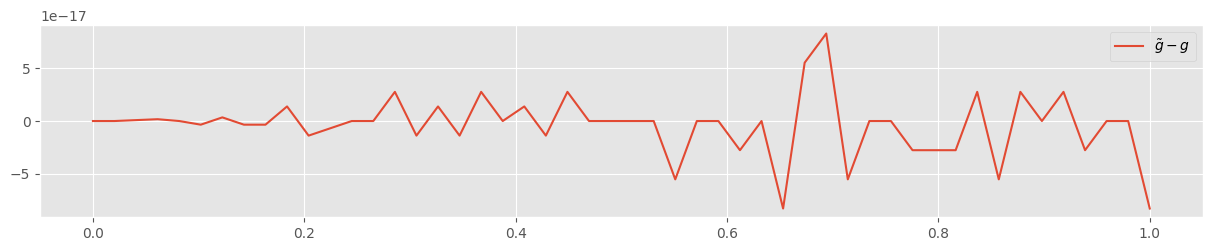

In [6]:
plt.figure(figsize=(15,2.5))
plt.plot(A, integral_closed(A) - B, label = r'$\tilde{g}-g$' )
plt.legend()
#plt.yscale('symlog',linthresh=1e-17)
plt.show()

If we wanted to compute the absolute value for even larger values of $\varepsilon$, we would obtain a conditional expression:
\begin{align*}
    \int\limits_{ B(0;\xi) }  |K| \, \mathrm{d} x
	= \frac{1}{4}
	\begin{cases}
		2 + \xi^2 \log \xi - \xi^2	& \text{if } \xi > 1,
		\\
		\xi^2 - \xi^2 \log \xi^2		& \text{if } \xi \in (0,1].
	\end{cases}
\end{align*}

In [7]:
def integral_numeric(ε, ep=1e-12):
    """
    Numerically approximates g(ε) = 1/(2π) ∫_0^ε ∫_0^2π s log(s) dθ ds
    """
    f = lambda θ, s: abs(s * np.log(s)) * 0.5 / np.pi
    return dblquad(f, 0, ε, 0, 2*np.pi, epsabs = ep, epsrel = ep)[0]

def integral_closed(ε):
    """
    Closed-form value: 2π log((u + √(ε² − v²))/2)
    """
    if ε <= 1.0:
        return 0.25 * ε**2.0 * (1.0 - np.log(ε**2) )
    else:
        return 0.25 * ( 2 + ε**2.0 * (np.log(ε**2) - 1.0) )

In [8]:
integral_numeric(2.0, ep=1e-14), integral_closed(2.0)

/opt/homebrew/Caskroom/miniforge/base/lib/python3.10/site-packages/scipy/integrate/_quadpack_py.py:1260: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  quad_r = quad(f, low, high, args=args, full_output=self.full_output,


(0.8862943611198909, np.float64(0.8862943611198906))

In [9]:
A = np.linspace(1e-12,10, 300)
B = [integral_numeric(a, ep=1e-14) for a in A]

/opt/homebrew/Caskroom/miniforge/base/lib/python3.10/site-packages/scipy/integrate/_quadpack_py.py:1260: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  quad_r = quad(f, low, high, args=args, full_output=self.full_output,


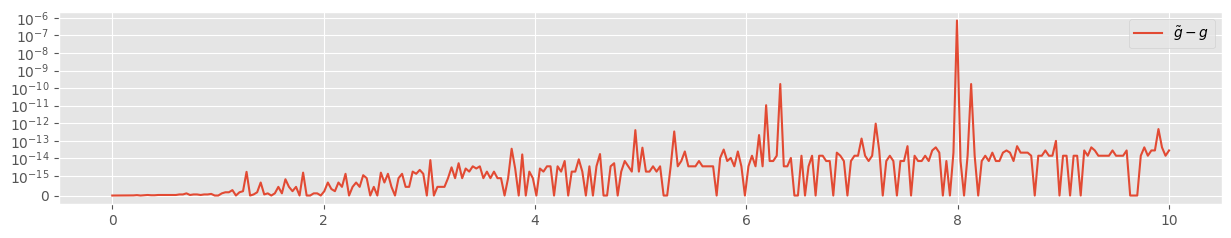

In [10]:
plt.figure(figsize=(15,2.5))
plt.plot(A, abs(B - np.asarray([integral_closed(a) for a in A])), label = r'$\tilde{g}-g$' )
plt.legend()
plt.yscale('symlog',linthresh=1e-15)
plt.show()

---

# Integral when intersection is an overlapping region

For the case where $x \in B_2(0;1-\varepsilon)^c$, we have that $x - \big( B_2(x;\varepsilon) \cap B_2(0;1) \big) = B_2(0;\varepsilon) \cap B_2(x;1)$. The resulting area resembles a centred ball $B_2(0;\varepsilon)$ with a flattened side. As a result of this observation and the fact that $K$ mantains a constant sign inside ◯, the integral over this region must be bounded by the integral defined over the ball; i.e.,
\begin{align*}
    \int\limits_{x - ●} -K(u) \, \dif u \leq \int\limits_{B_2(0;\varepsilon)} -K(u) \, \dif u = -\frac{\varepsilon^2}{4} (\log \varepsilon^2 -1),
\end{align*}
where the sign comes from realising that $|K|=-K$.

We can do more than this, though. Observe that the region can be characterised by the cutting points where the closure of the two balls intersect. The intersection points are completely characterised by the point $x$ as follows:
\begin{align*}
    u = \frac{1}{\|x\|} x,
    \qquad
    u_\perp = \begin{pmatrix} u_2 \\ -u_1   \end{pmatrix},
    \qquad
    t = \frac{\varepsilon^2 + \|x\|^2 -1}{2 \|x\|},
    \qquad
    h = \sqrt{\varepsilon^2 - t^2},
    \qquad
    v \in \{t u \pm h u_\perp\}.
\end{align*}
It is further possible to parametrise $x - ●$ with these points and their angles with respect to the origin. However, let's focus on the case where $x = (-a,0)$ with $a \in [0,1]$. In this case, we have that
\begin{align*}
    u = \frac{1}{a} \begin{pmatrix} -a \\ 0   \end{pmatrix} = \begin{pmatrix} -1 \\ 0   \end{pmatrix},
    \qquad
    u_\perp = \begin{pmatrix} 0 \\ 1   \end{pmatrix},
    \qquad
    t = \frac{\varepsilon^2 + a^2 -1}{2 a},
    \qquad
    h = \sqrt{\varepsilon^2 - t^2},
    \qquad
    v \in \left\{ \begin{pmatrix} -t \\ \pm h   \end{pmatrix} \right\}.
\end{align*}
Thus
\begin{align*}
    v \in \left\{
    \frac{1}{2a}
    \begin{pmatrix}
    1-a^2-\varepsilon^2
    \\
    \pm \sqrt{ \big((a+\varepsilon)^2-1\big) \big(1-(a-\varepsilon)^2\big) }
    \end{pmatrix} \right\}.
\end{align*}
Notice that, as expected, the vector $v_+$ has a positive vertical component. We call $\varphi$ the angle of $v_+$ which is given by the expression:
\begin{align*}
    \varphi = \operatorname{arccos}\left( -\frac{t}{\varepsilon} \right) = \operatorname{arccos}\left( \frac{1 - a^2 - \varepsilon^2}{2a\varepsilon} \right).
\end{align*}
Thence, the region $◓ = (x - ●) \cap \mathbb{R} \times \mathbb{R}_{\geq 0}$ can be represented by
\begin{align*}
    ◓ = \big\{ (r,\theta): \, r \in [0,\varepsilon] \wedge \theta \in [\varphi,\pi] \big\} \cup \bigg\{ (r,\theta): \, r \in \Big[0, a \cos(\theta-\psi)+ \sqrt{1 - a^2 \sin^2(\theta-\psi)} \Big] \wedge \theta \in [0,\varphi] \bigg\}.
\end{align*}
The radius $s(\theta) = a \cos(\theta-\psi) + \sqrt{1 - a^2 \sin^2(\theta-\psi)}$ comes from the polar representation of the constaint $\|v - x\|^2 = r^2 - 2 a r \cos(\theta - \psi) + a^2 = 1$ which determines the maximum radius in the flattened area, and $\psi$ is the angle of $x$, which in this case corresponds to $\psi = \pi$.

Thus we can simplify $s(\theta)$ to 
\begin{align*}
    s(\theta) = -a \cos(\theta) + \sqrt{ 1 - a^2 \sin^2(\theta) }.
\end{align*}
Then we obtain that
\begin{align*}
    \iint\limits_{◓} K(u) \dif u = \int\limits_\varphi^\pi \int\limits_0^\varepsilon r K(r) \dif r \dif \theta
    +
    \int\limits_0^\varphi \int\limits_0^{s(\theta)} r K(r) \dif r \dif \theta.
\end{align*}
The first integral has an exact solution
\begin{align*}
    \int\limits_\varphi^\pi \int\limits_0^\varepsilon r K(r) \dif r \dif \theta
    =
    \frac{\pi - \varphi}{8\pi} \varepsilon^2 ( \log \varepsilon^2 - 1).
\end{align*}
In contrast, the second interval can be approximated numerically from the reduction
\begin{align*}
    \int\limits_0^\varphi \int\limits_0^{s(\theta)} r K(r) \dif r \dif \theta
    =
    \int\limits_0^\varphi \frac{1}{4} s^2(\theta) \big( \log s^2(\theta) - 1 \big) \dif \theta.
\end{align*}

In [11]:
from warnings import warn

In [12]:
def exact_g1(a, ε):
    """
    Compute G_ε(x) = (1/2π) ∫_φ^π ∫_0^ε r log(r) dr dθ
    """
    φ = np.acos( 0.5 * (1.0 - a**2 - ε**2)/( a * ε ) )
    
    return 0.125 * (np.pi - φ) * ε**2 * (2.0 * np.log(ε) - 1.0) / np.pi

def integral_numeric(a, ε, eps=1e-10):
    """
    Numerically approximates G_ε(x) = (1/2π) ∬_{x - ●} log(|x|) dA   for x = (-a,0) and a in (1-ε,1]
    """
    if a <= 1.0 - ε:
        warn("Warning: a is too small. Defaulting to smallest possible value.")
        a = 1.0 - ε + 1e-15
    if abs(1.0-a) < 1e-15:
        # At a = 1.0, the numerical method fails
        a = 1.0 - 1e-15
    
    f = lambda r, θ: r * np.log( r )
    #print(0.5 * (1.0 - a**2 - ε**2)/( a * ε ))
    φ = np.acos( 0.5 * (1.0 - a**2 - ε**2)/( a * ε ) )
    
    # From radial symmetry, we need only the upper part of the region, then we multiply by 2. 
    # We thus split the upper part into two polar regions
    
    '''
        Approximate g_1 = ∫_φ^π ∫_0^ε r log(r) dr dθ (although, this one is known to be 0.25 (π - φ) ε^2 (log ε^2 - 1) 
    '''
    #g_1 = dblquad(f, φ, np.pi, 0, ε, epsabs = eps, epsrel = eps)[0]
    # Personal comment: I truncated the function up to here and tested it against 2 exact_g1(a, ε) yielding an error around 1e-19
    g_1  = exact_g1(a, ε)
    g_1 *= (2 * np.pi)        # Correct integral
    
    '''
        Approximate g_2 = ∫_0^φ ∫_0^s(θ) r log(r) dr dθ 
    '''
    #s_aε = lambda θ: a * np.cos(θ-np.pi) + np.sqrt( 1.0 - a**2 * np.sin(θ-np.pi)**2 )
    s_aε = lambda θ: -a * np.cos(θ) + np.sqrt( 1.0 - a**2 * np.sin(θ)**2 )
    
    # Since we have an antiderivative of r log(r), we can avoid using a double integral:
    #g_2  = dblquad(f, 0, φ, lambda θ: 0.0, s_aε, epsabs = eps, epsrel = eps)[0]
    
    S_aε = lambda θ: 0.25 * s_aε(θ)**2 * (2.0 * np.log(s_aε(θ)) - 1.0)
    g_2 = quad(S_aε, 0, φ, epsabs=eps, epsrel=eps)[0]
    
    
    '''
        Add terms and correct weights:
    '''
    #print(φ,g_1/np.pi)
    G  = g_1 + g_2
    G /= np.pi    # 0.5 * 2 = 1.0
    
    return G

In [13]:
ε = 1e-2
integral_numeric(1.0-ε + 1e-5, ε, eps=1e-14)

np.float64(-0.0002552541171894558)

In [14]:
0.25 * ε**2 * (2.0 * np.log(ε) - 1.0)

np.float64(-0.00025525850929940453)

Let's evaluate the integral for all feasible values of $a$:

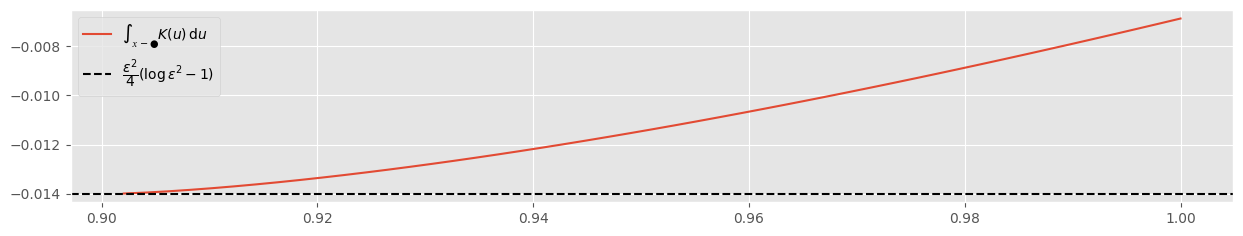

In [15]:
# Display values of integral over an interval for a
ε = 1e-1
A = np.linspace(1.0-ε, 1.0)[1:]
B = np.asarray([integral_numeric(a, ε, eps=1e-14) for a in A])

plt.figure(figsize=(15,2.5))
#plt.plot(A, exact_g1(A, ε) * 2 )
#plt.plot(A, [integral_numeric(a, ε, eps=1e-14) for a in A])
plt.plot(A, B, label = r'$\int_{𝑥−●} K(u) \, \mathrm{d}u$' )
plt.axhline( 0.25 * ε**2 * (np.log(ε**2) - 1.0), c ='black', linestyle = '--' , label = r'$\dfrac{\varepsilon^2}{4}(\log \varepsilon^2 -1)$' )
plt.legend()

We can then generalise the function for any argument:

In [16]:
def G(a, ε, eps=1e-10):
    """
    Numerically approximates G_ε(x) = (1/2π) ∬_{x - ●} log(|x|) dA for x in (a,0) and a in [0,1]
    """
    x = abs(a)
    if x <= 1.0 - ε:
        g = 0.25 * ε**2 * (2.0 * np.log(ε) - 1.0)
    else:
        g = integral_numeric(x, ε, eps)
    return g

G_num = G

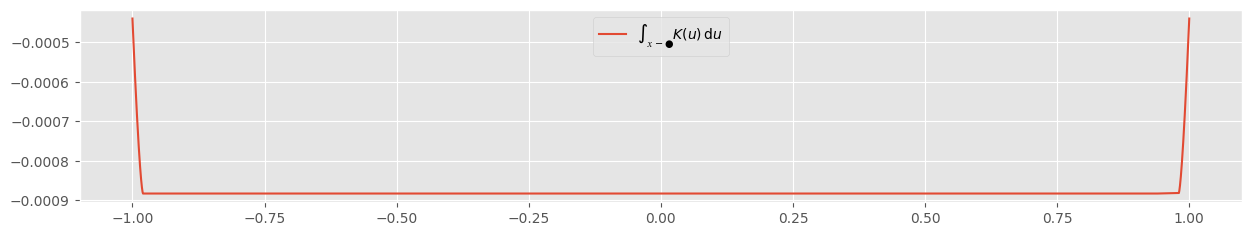

In [17]:
# Display numerical convolution for ‖x‖ ∈ [-1,1]
ε = 2e-2
A = np.r_[np.linspace(-1.0, -1.0+ε)[:-1], np.linspace(-1.0+ε, 1.0-ε)[:-1], np.linspace(1.0-ε, 1.0)[1:]]
B = np.asarray([G(a, ε, eps=1e-14) for a in A])

plt.figure(figsize=(15,2.5))
plt.plot(A, B, label = r'$\int_{𝑥−●} K(u) \, \mathrm{d}u$' )
plt.legend()
plt.show()

# Exact integral by swapping the order of integration

There is an alternative integration method that also reduces the problem to a 1-dimensional integral. To see this, we need to exchange the order of integration of the integral
\begin{align*}
    H(a) = \int\limits_0^\varphi \int\limits_0^{s(\theta)} r K(r) \dif r \dif \theta 
\end{align*}
Recall that $s(\theta) = -a \cos(\theta) + \sqrt{ 1 - a^2 \sin^2(\theta) }$. Thus, for a fixed $r>0$, the condition $r \leq s$ is equivalent to $r + a \cos(\theta) \leq \sqrt{ 1 - a^2 (1 - \cos^2(\theta)) }$. Squaring both sides, we obtain that
\begin{align*}
    r^2 + 2 a r \cos (\theta) \leq 1-a^2 
    \qquad\text{and}\qquad
    \cos(\theta) \leq \frac{1-a^2-r^2}{2ar} = \ell(r).
\end{align*}
Since both $a>0$ and $r\geq 0$, we have that $\ell(r) \geq -\dfrac{r}{a}$, thus for each $r$, the admissible $\theta$ lie within $\cos(\theta) \leq \ell(r)$. As $\cos$ is decreasing on $[0,\pi]$ and $\varphi < \pi$, we obtain the following admissible interval for $\theta$:
\begin{align*}
    \theta \in [t(\theta),\varphi],
    \qquad\text{where}\qquad
    t(\theta) = 
    \begin{cases}
        0 & \text{if } \ell(r) > 1,
        \\
        \operatorname{arccos}(\ell(r)), & \text{if } \cos(\varphi) \leq \ell(r) \leq 1.
    \end{cases}
\end{align*}
The threshold $\ell(r) \geq 1$ is equivalent to $r \leq 1-a$. In contrast, $r$ varies from $0$ to the top of the region determined by $s(\varphi)$, as $s$ is monotone increasing.

As a result, we have that 
\begin{align*}
    H(a) &= \int\limits_0^{s(\varphi)} \int\limits_{\ell(r)}^\varphi  r K(r) \dif \theta  \dif r 
    = \int\limits_0^{1-a} \varphi r K(r) \dif r + \int\limits_{1-a}^{s(\varphi)} \left( \varphi - \operatorname{arccos}\left( \frac{1-a^2-r^2}{2ar} \right) \right) r K(r) \dif r
    \\
    &= \int\limits_0^{s(\varphi)} \varphi r K(r) \dif r - \int\limits_{1-a}^{s(\varphi)} \operatorname{arccos}\left( \frac{1-a^2-r^2}{2ar} \right) r K(r) \dif r.
\end{align*}

We already know that 
\begin{align*}
    \int\limits_0^{s(\varphi)} \varphi r K(r) \dif r 
    = \frac{\varphi}{4 (2\pi)} s^2(\varphi) \big( \log s^2(\varphi) - 1\big).
\end{align*}
Our main question now is to determine whether we can find an explicit solution to
\begin{align*}
    h_1(a) := \frac{1}{2\pi} \int \operatorname{arccos}\left( \frac{1-a^2-r^2}{2ar} \right) r \log(r) \dif r.
\end{align*}

Let $u \equiv \operatorname{arccos} \ell(r) = \operatorname{arccos}\left( \dfrac{1-a^2-r^2}{2ar} \right) $ and $\dif v \equiv r \log(r)$, this yields
\begin{align*}
    h_1(a) = \frac{1}{2\pi} \left[ \frac{1}{4}r^2 (\log r^2 -1) \operatorname{arccos} \ell(r) + \frac{1}{4} \int  r^2 (\log r^2 -1) \frac{ \ell'(r) }{\sqrt{1 - \ell^2(r)}} \dif r  \right]
\end{align*}
Here, we have that
\begin{align*}
    \ell'(r) = \frac{1}{2ar^2} (a^2 - r^2 - 1)
    \qquad\text{and}\qquad
    \sqrt{1 - \ell^2(r)} = \frac{1}{2ar} \sqrt{ \big((a+1)^2 - r^2\big) \big(r^2 - (1-a)^2\big) }
\end{align*}
Now let us introduce the change of variables $\phi \equiv \operatorname{arccos} \frac{1 + a^2 - r^2}{2a}$  which maps the range $[1-a,1+a]$ to $[0,\pi]$ through the relationship $r^2 \equiv 1 + a^2 - 2a \cos(\phi)$. Through implicit differentiation, we obtain that $ r \dif r \equiv a \sin(\phi) \dif \phi$. Moreover,
\begin{align*}
    \big((a+1)^2 - r^2\big) \big(r^2 - (1-a)^2\big) = \big( 2 a - (r^2 - 1 - a^2) \big) \big( (r^2 - 1 - a^2) + 2 a   \big)
    \equiv 4a^2 (1 + \cos(\phi))(1 - \cos(\phi) ) = 4 a^2  \sin^2(\phi).
\end{align*}
and the nonnegativity of sine over $[0,\pi]$ yields $\sqrt{ \big((a+1)^2 - r^2\big) \big(r^2 - (1-a)^2\big) } \equiv 2 a \sin(\phi)$ and we obtain that
\begin{align*}
    \frac{ \ell'(r) }{\sqrt{1 - \ell^2(r)}} \equiv \frac{1}{r} \frac{a \cos \phi - 1}{a \sin \phi},
    \qquad
    r^2 \cdot \frac{ \ell'(r) }{\sqrt{1 - \ell^2(r)}} \dif r  \equiv (a \cos \phi - 1) \dif \phi.
\end{align*}
Thus
\begin{align*}
    h_2(a) := \int  r^2 (\log r^2 -1) \frac{ \ell'(r) }{\sqrt{1 - \ell^2(r)}} \dif r 
    =
    -\int (1 - a \cos \phi) \big( \log(1 + a^2 - 2a \cos\phi ) -1  \big) \dif \phi
\end{align*}

Here is where things get messy. Let us expand the integrand as
\begin{align*}
    h_2(a) 
    =
    -\left[   \int \log(1 + a^2 - 2a \cos\phi ) \dif \phi  
            - \int (a \cos \phi)\log(1 + a^2 - 2a \cos\phi ) \dif \phi  
            + \int a \cos \phi -1 \dif \phi
    \right].
\end{align*}

## 1

First, notice that $\log(1+ a^2 - 2a \cos \phi) = \log |1 - a e^{i\phi}|^2 = \log(1-a e^{i\phi}) + \log(1-a e^{-i\phi})$. Now, the dilogarithm satisfies the equation
\begin{align*}
    \frac{\dif}{\dif x} \mathrm{Li}_2 (x) = -\frac{\log(1-x)}{x}.
\end{align*}
Then, the chain rule allows us to write
\begin{align*}
    \frac{\dif}{\dif \phi} \mathrm{Li}_2 ( a e^{i \phi} ) 
    = \mathrm{Li}_2'(a e^{i \phi} ) \frac{\dif}{\dif \phi} (a e^{i \phi} )
    = -\frac{\log(1-a e^{i \phi})}{a e^{i \phi}} a i e^{i \phi} = -i\log(1-a e^{i \phi}).
\end{align*}
As a result, we have that
\begin{align*}
    \int \log(1-a e^{\pm i  \phi}) \dif \phi = \pm i \, \mathrm{Li}_2 ( a e^{i \phi} ) + C.
\end{align*}

In [18]:
import sympy as sp
from scipy.special import spence # Use as spece(1.0-z)

In [19]:
ϕ, a = sp.symbols('ϕ, a', real=True, nonnegative = True)

In [20]:
L_1 = sp.I * sp.polylog(2, a*sp.exp( sp.I * ϕ))
L_2 = sp.I * sp.polylog(2, a*sp.exp(-sp.I * ϕ))

In [21]:
display( sp.expand_func(sp.diff(L_1, ϕ)), sp.expand_func(sp.diff(L_2, ϕ)) )

log(-a*exp(I*ϕ) + 1)

-log(-a*exp(-I*ϕ) + 1)

Thus, we have that
\begin{align*}
    \int \log(1 + a^2 - 2a \cos\phi )  \dif \phi = i \big( \mathrm{Li}_2 ( a e^{i \phi} ) - \mathrm{Li}_2 ( a e^{-i \phi} ) \big) + C
    = 2 i \cdot i \Im \big( \mathrm{Li}_2 ( a e^{i \phi} ) \big)  + C
    = \boxed{- 2 \Im \big( \mathrm{Li}_2 ( a e^{i \phi} ) \big) + C.}
\end{align*}

In [22]:
sp.expand_func(sp.diff(L_1-L_2, ϕ))

log(-a*exp(-I*ϕ) + 1) + log(-a*exp(I*ϕ) + 1)

In [23]:
sp.expand_func((-2 * sp.im( sp.polylog(2, a*sp.exp( sp.I * ϕ)) )).diff(ϕ) ).rewrite(sp.cos).simplify()

log(a**2 - 2*a*cos(ϕ) + 1)

Observe that if $\phi = 0$, then $- 2 \Im \big( \mathrm{Li}_2 ( a e^{i \phi} ) \big) = 0$.

In [24]:
ε  = 6e-2
Φ = np.linspace(0,np.pi)
A = np.linspace(1.0 - ε, 1.0,10)
L_exa = np.asarray([[ -2.0 * (spence( 1 - aₙ * np.exp( (1j) * φₙ) ).imag ) for φₙ in Φ] for aₙ in A])
L_num = np.asarray([[quad(lambda θ: np.log( (1.0 - aₙ)**2 + 4.0*aₙ*np.sin(0.5*θ)**2 ), #np.log(1.0 + aₙ**2 - 2.0 * aₙ * np.cos(θ) ), 
                          0, ϕₙ, epsabs=1e-13, epsrel=1e-13)[0] for ϕₙ in Φ] for aₙ in A])
L_num[:,0] = 0.0

/var/folders/1g/8szp6jr52h1byl43_1lx7zlm0000gn/T/ipykernel_9710/3690487554.py:5: RuntimeWarning: divide by zero encountered in log
  L_num = np.asarray([[quad(lambda θ: np.log( (1.0 - aₙ)**2 + 4.0*aₙ*np.sin(0.5*θ)**2 ), #np.log(1.0 + aₙ**2 - 2.0 * aₙ * np.cos(θ) ),
/var/folders/1g/8szp6jr52h1byl43_1lx7zlm0000gn/T/ipykernel_9710/3690487554.py:5: IntegrationWarning: Extremely bad integrand behavior occurs at some points of the
  integration interval.
  L_num = np.asarray([[quad(lambda θ: np.log( (1.0 - aₙ)**2 + 4.0*aₙ*np.sin(0.5*θ)**2 ), #np.log(1.0 + aₙ**2 - 2.0 * aₙ * np.cos(θ) ),
/var/folders/1g/8szp6jr52h1byl43_1lx7zlm0000gn/T/ipykernel_9710/3690487554.py:5: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  L_num = np.asarray([[quad(lambda θ: np.log( (1.0 - aₙ)**2 + 4.0*aₙ*np.sin(0.5*θ)**2 ), #np.log(1.0 + aₙ**2 - 2.0 * aₙ * np.cos(θ) ),


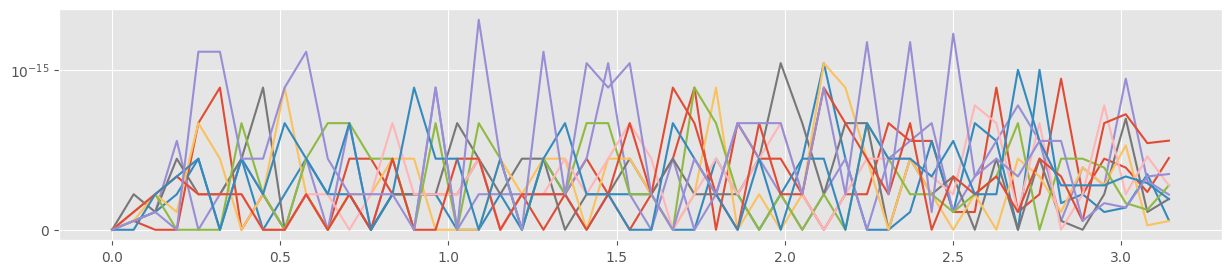

In [25]:
# Plot error curves for ϕ ∈ [0,π] for different values of a in [1-ε,1]
plt.figure(figsize=(15,3))
plt.plot(Φ, abs(L_exa.T - L_num.T))
plt.yscale('symlog',linthresh=1e-15)

---

## 2

Computing the integral of $(a \cos \phi) \log(1+ a^2 - 2a \cos\phi)$ can be done in a similar fashion. To see this, note that $\cos \phi = \frac{1}{2}(e^{i\phi} + e^{-i\phi})$, then
\begin{align*}
    \int (a \cos\phi) \log(1 + a^2 - 2a \cos\phi )  \dif \phi = 
    \int \frac{a}{2} ( e^{i\phi} + e^{-i\phi} )  \big( \log(1-a e^{i\phi}) + \log(1-a e^{-i\phi}) \big)  \dif \phi.
\end{align*}
Now the change of variables $z \equiv e^{i\phi}$ yields
\begin{align*}
    \int \frac{a}{2} e^{i\phi} \log(1-a e^{i\phi}) \dif \phi
    =
    \frac{1}{2i}(1 - a e^{i\phi}) \left(1 - \log(1 - a e^{i\phi}) \right) + C.
\end{align*}
Similarly, it is possible to arrive to
\begin{align*}
    \int \frac{a}{2} ( e^{i\phi} + e^{-i\phi} )  \log(1-a e^{i\phi}) \dif \phi
    =
    -\frac{a^2}{2} \phi + a \sin\phi \log(1-a e^{i\phi}) - \frac{1}{2i}\left[(1-a^2)\log(1-a e^{i\phi}) + a^2 + a e^{i\phi}\right] + C.
\end{align*}
And likewise
\begin{align*}
    \int \frac{a}{2} (e^{i\phi} + e^{-i\phi}) \log(1-a e^{-i\phi}) \dif \phi
    = a\sin\phi \log(1-ae^{-i\phi}) - \frac{a^2}{2}\phi + \frac{1}{2i}\left[(1-a^2)\log(1-ae^{-i\phi}) + a^2 + a e^{-i\phi}\right] + C.
\end{align*}
Finally, using $\Im \log(1-a e^{i\phi}) = -\operatorname{arctan} \frac{a \sin\phi}{1-a \cos\phi}$, we get
\begin{align*}
%https://chat.deepseek.com/share/qhhue10hqduzvdmjy9
    \int (a \cos\phi) \log(1 + a^2 - 2a \cos\phi )  \dif \phi = 
    \boxed{-a^2 \phi + (1-a^2)\arctan\left(\frac{a\sin\phi}{1-a\cos\phi}\right) + a\big( \log(1-2a\cos\phi+a^2) - 1 \big)\sin\phi  + C.}
\end{align*}






There is an alternative form of the integral as well:
\begin{align*}
% Found through Wolfram, verified through direct differentiation, see https://chat.deepseek.com/share/zodarlj2c2i48cs60m
    \int (a \cos \phi) \log(1+ a^2 - 2a \cos\phi) \dif \phi 
    =
    %-\frac{1}{2} (1 + a^2) \phi + (a^2 - 1) \operatorname{arctan} \frac{ \left( (1 + a) \tan\left(\frac{\phi}{2} \right) \right)}{a - 1} + a \big(-1 + \log\big(1 + a^2 - 2 a \cos(\phi)\big) \Big) \sin(\phi).
    \boxed{
        -\frac{1}{2} (1 + a^2) \phi + (1 - a^2) \operatorname{arctan} \left( \frac{1+a}{1-a} \tan\frac{\phi}{2} \right) + a \big( \log\big(1 + a^2 - 2 a \cos(\phi)\big) -1 \Big) \sin(\phi).
    }
\end{align*}

In [26]:
# We can verify the integral through symbolic differentiation
L_3a = -a**2*ϕ + (1 - a**2) * sp.atan( a * sp.sin(ϕ) / (1 - a * sp.cos(ϕ)) ) + a*( sp.log(1 + a**2 - 2*a*sp.cos(ϕ) ) -1 ) * sp.sin(ϕ)
display(L_3a)
L_3a.diff(ϕ).simplify()

-a**2*ϕ + a*(log(a**2 - 2*a*cos(ϕ) + 1) - 1)*sin(ϕ) + (1 - a**2)*atan(a*sin(ϕ)/(-a*cos(ϕ) + 1))

a*log(a**2 - 2*a*cos(ϕ) + 1)*cos(ϕ)

In [27]:
# We can verify the integral through symbolic differentiation
L_3 = -sp.S(1)/2 * (1+a**2)*ϕ + (a**2 - 1) * sp.atan( (1+a) * sp.tan(ϕ/2)/(a-1) ) + a*( sp.log(1 + a**2 - 2*a*sp.cos(ϕ) ) -1 ) * sp.sin(ϕ)
display(L_3)
G = L_3.diff(ϕ) - a* sp.log(1 + a**2 - 2*a*sp.cos(ϕ) ) * sp.cos(ϕ)
sp.simplify(G)

a*(log(a**2 - 2*a*cos(ϕ) + 1) - 1)*sin(ϕ) + ϕ*(-a**2/2 - 1/2) + (a**2 - 1)*atan((a + 1)*tan(ϕ/2)/(a - 1))

0

Notice that regardless of the formulation, if $a$ or $\phi$ are $0$, both expressions equal $0$ as well. If $a=1$, both expressions also reduce to $- \phi + \big( \log(2 - 2 \cos\phi) - 1 \big) \sin \phi$ which is continuous at $0$. 

In [28]:
ε  = 6e-2
Φ = np.linspace(0,np.pi)
A = np.linspace(1.0 - ε, 1.0,10)
L_exa = np.asarray([[ -aₙ**2 * φₙ + (1 - aₙ**2) * np.atan( aₙ * np.sin(φₙ) / (1 - aₙ * np.cos(φₙ)) ) + aₙ*( np.log(1 + aₙ**2 - 2*aₙ*np.cos(φₙ) ) -1 ) * np.sin(φₙ)
    for φₙ in Φ] for aₙ in A])
L_num = np.asarray([[quad(lambda θ: ( aₙ * np.cos(θ) ) * np.log( (1.0 - aₙ)**2 + 4.0*aₙ*np.sin(0.5*θ)**2 ),
                          0, ϕₙ, epsabs=1e-13, epsrel=1e-13)[0] for ϕₙ in Φ] for aₙ in A])
L_num[:,0] = 0.0
L_exa[:,0] = 0.0

/var/folders/1g/8szp6jr52h1byl43_1lx7zlm0000gn/T/ipykernel_9710/3713253201.py:4: RuntimeWarning: invalid value encountered in scalar divide
  L_exa = np.asarray([[ -aₙ**2 * φₙ + (1 - aₙ**2) * np.atan( aₙ * np.sin(φₙ) / (1 - aₙ * np.cos(φₙ)) ) + aₙ*( np.log(1 + aₙ**2 - 2*aₙ*np.cos(φₙ) ) -1 ) * np.sin(φₙ)
/var/folders/1g/8szp6jr52h1byl43_1lx7zlm0000gn/T/ipykernel_9710/3713253201.py:4: RuntimeWarning: divide by zero encountered in log
  L_exa = np.asarray([[ -aₙ**2 * φₙ + (1 - aₙ**2) * np.atan( aₙ * np.sin(φₙ) / (1 - aₙ * np.cos(φₙ)) ) + aₙ*( np.log(1 + aₙ**2 - 2*aₙ*np.cos(φₙ) ) -1 ) * np.sin(φₙ)
/var/folders/1g/8szp6jr52h1byl43_1lx7zlm0000gn/T/ipykernel_9710/3713253201.py:4: RuntimeWarning: invalid value encountered in scalar multiply
  L_exa = np.asarray([[ -aₙ**2 * φₙ + (1 - aₙ**2) * np.atan( aₙ * np.sin(φₙ) / (1 - aₙ * np.cos(φₙ)) ) + aₙ*( np.log(1 + aₙ**2 - 2*aₙ*np.cos(φₙ) ) -1 ) * np.sin(φₙ)
/var/folders/1g/8szp6jr52h1byl43_1lx7zlm0000gn/T/ipykernel_9710/3713253201.py:6: RuntimeWarn

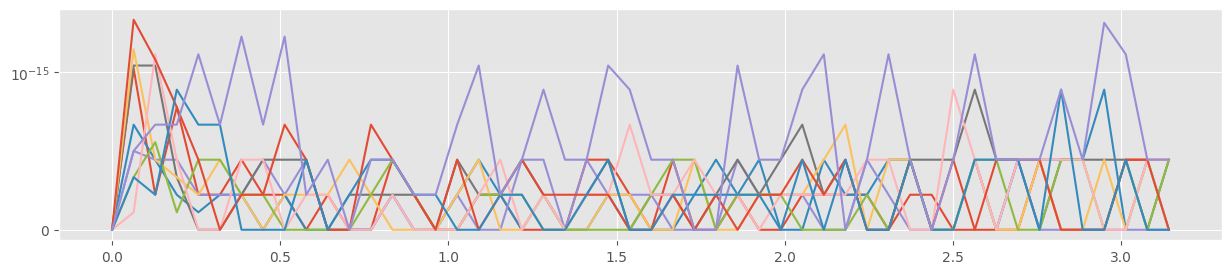

In [29]:
# Plot error curves for ϕ ∈ [0,π] for different values of a in [1-ε,1]
plt.figure(figsize=(15,3))
plt.plot(Φ, abs(L_exa.T - L_num.T))
plt.yscale('symlog',linthresh=1e-15)

## 3
Finally, we have that $\int a \cos \phi -1 \dif \phi = -\phi + a \sin(\phi) + C$. Thus, we can write $h_2$ as
\begin{align*}
    h_2(a) = 
        \boxed{
        2 \Im \big( \mathrm{Li}_2 ( a e^{i \phi} ) \big)
        + (1-a^2)\left[ \phi + \arctan\left(\frac{a\sin\phi}{1-a\cos\phi}\right)\right] + a\big( \log(1-2a\cos\phi+a^2) - 2 \big)\sin\phi + C.}
\end{align*}
Observe that $\arctan\left(\dfrac{a\sin\phi}{1-a\cos\phi}\right) = \operatorname{atan2}({a\sin\phi}, {1-a\cos\phi})$. Additionally, 
\begin{align*}
    h_2(1) &= 2 \Im \big( \mathrm{Li}_2 ( e^{i \phi} ) \big)
        + \big( \log(2-2\cos\phi) - 2 \big)\sin\phi + C
    \\
    \lim_{\phi\to 0} h_2(1) &= 2 \Im \big( \mathrm{Li}_2 ( e^{i \phi} ) \big) \Big|_{\phi = 0} = 0.
\end{align*}

In [30]:
def h_2(a, ϕ):
    # Dilog part
    h_2a = 2.0 * spence( 1.0 - a * np.exp( 1j * ϕ) ).imag
    # Angular part
    h_2b = (1.0 - a**2) * ( ϕ + np.arctan2(a * np.sin(ϕ), 1.0 - a * np.cos(ϕ)) )
    # Sine part
    y_a = (1 - a)**2 + 4.0 * a * np.sin(0.5 * ϕ)**2        # 0 when (a,ϕ) = (1,0)
    y_b = np.zeros_like(y_a)
    np.log(y_a, out = y_b, where = (y_a > 0))              # log(0) is 0 for limit to work
    h_2c = a * ( y_b - 2.0 ) * np.sin(ϕ)
    
    return h_2a + h_2b + h_2c

We can test our exact solution against a numerical implementation:
\begin{align*}
    h_2(a) 
    =
    \int (a \cos \phi - 1) \bigg( \log\Big( (1 - a)^2 + 4 a^2 \sin \frac{\phi}{2} \Big) -1  \bigg) \dif \phi
\end{align*}

In [31]:
ε  = 6e-4
Φ = np.linspace(0,np.pi)
A = np.linspace(1.0 - ε, 1.0,10)
L_exa = h_2(A[::,None],Φ)
L_num = np.asarray([[quad(lambda θ: ( aₙ * np.cos(θ) - 1.0 ) * (np.log( (1.0 - aₙ)**2 + 4.0*aₙ*np.sin(0.5*θ)**2 ) - 1.0),
                          0, ϕₙ, epsabs=1e-13, epsrel=1e-13)[0] for ϕₙ in Φ] for aₙ in A])

/var/folders/1g/8szp6jr52h1byl43_1lx7zlm0000gn/T/ipykernel_9710/26331611.py:5: RuntimeWarning: divide by zero encountered in log
  L_num = np.asarray([[quad(lambda θ: ( aₙ * np.cos(θ) - 1.0 ) * (np.log( (1.0 - aₙ)**2 + 4.0*aₙ*np.sin(0.5*θ)**2 ) - 1.0),
/var/folders/1g/8szp6jr52h1byl43_1lx7zlm0000gn/T/ipykernel_9710/26331611.py:5: RuntimeWarning: invalid value encountered in scalar multiply
  L_num = np.asarray([[quad(lambda θ: ( aₙ * np.cos(θ) - 1.0 ) * (np.log( (1.0 - aₙ)**2 + 4.0*aₙ*np.sin(0.5*θ)**2 ) - 1.0),
/var/folders/1g/8szp6jr52h1byl43_1lx7zlm0000gn/T/ipykernel_9710/26331611.py:5: IntegrationWarning: Extremely bad integrand behavior occurs at some points of the
  integration interval.
  L_num = np.asarray([[quad(lambda θ: ( aₙ * np.cos(θ) - 1.0 ) * (np.log( (1.0 - aₙ)**2 + 4.0*aₙ*np.sin(0.5*θ)**2 ) - 1.0),


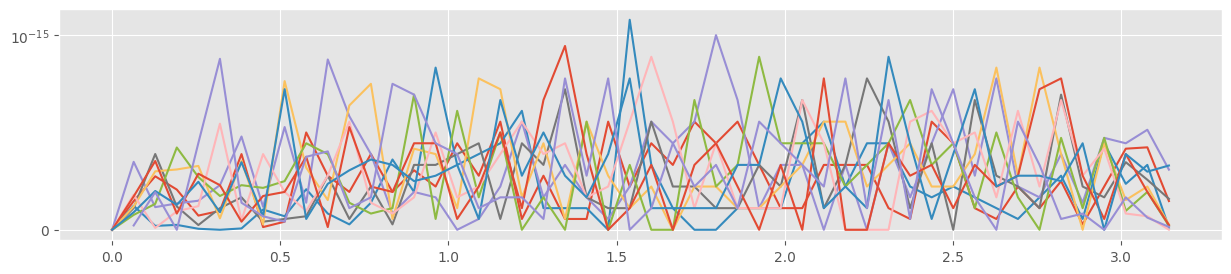

In [32]:
# Plot error curves for ϕ ∈ [0,π] for different values of a in [1-ε,1]
plt.figure(figsize=(15,3))
plt.plot(Φ, abs(L_exa.T - L_num.T))
plt.yscale('symlog',linthresh=1e-15)

---

Now to compute
\begin{align*}
    h_1(a) &= \frac{1}{2\pi} \int \operatorname{arccos}\left( \frac{1-a^2-r^2}{2ar} \right) r \log(r) \dif r
    \\
    &= \frac{1}{8\pi} \left[ r^2 (\log r^2 -1) \operatorname{arccos} \left( \dfrac{1-a^2-r^2}{2ar} \right) +  h_2(a)[\phi(r)]  \right],
\end{align*}
recall that $r^2 \equiv 1 + a^2 - 2a \cos(\phi)$, from which $\phi(r) = \arccos \frac{1 + a^2 - r^2}{2a}$. Replacing this expression in $h_2$ yields the following expression:
\begin{align*}
    h_2(a)[\phi(r)]  =
    2 \Im \mathrm{Li}_2 \left( \frac{1}{2} \Big( 1+a^2-r^2 + i \sqrt{4 a^2 - (1+a^2-r^2)^2} \Big) \right)
        + (1-a^2)\left[ \arccos \left(\frac{1 + a^2 - r^2}{2a}\right) + \arctan\left(\frac{ \sqrt{4 a^2 - (1+a^2-r^2)^2} }{1-a^2 + r^2 }\right)\right] + \big( \log r - 1 \big) \sqrt{4 a^2 - (1+a^2-r^2)^2} + C.
\end{align*}
Notice that it is simpler to just evaluate $h_2$, which is numerically stable, at $\phi(r)$ rather than use its representation in $r$.

Let $p_1(r) := \frac{1-a^2-r^2}{2ar}$ and $p_2(r) := \frac{1+a^2-r^2}{2a}$. We need to guarantee that $p_1, p_2 \in [-1,1]$. For $a \in [1-\varepsilon,1]$, we have that $p_1$ and $p_2$ are feasible if $r \in [1-a,1+a]$.
As a result, we will test
\begin{align*}
    %h_1(a) \bigg|_{1-a}^{1+a} = 
    \frac{1}{2\pi} \int\limits_{1-a}^{1+a} \operatorname{arccos}\left( \frac{1-a^2-r^2}{2ar} \right) r \log(r) \dif r
    =
    h_1(a)[1+a] - h_1(a)[1-a].
\end{align*}

Finally, note that if $a=1$, then
\begin{align*}
    \psi_1 = \frac{1-a^2-r^2}{2ar} \bigg|_{a=1} \frac{-r^2}{2r} = -\frac{1}{2} r,\qquad
    \psi_2 = \frac{1+a^2-r^2}{2a} \bigg|_{a=1} = 1 - \frac{1}{2} r^2,
\end{align*}
and thus
\begin{align*}
    h_1(1)[r] = \frac{1}{8\pi} \left[ r^2 (\log r^2 - 1)\arccos\left(-\frac{1}{2} r\right) + h_2(1)[\phi(r)] \bigg|_{\phi(r) =\arccos \psi_2} \right] 
\end{align*}

In [33]:
def h_1(a, r):
    a = np.asarray(a)
    r = np.asarray(r)
    
    ''' Angular part '''
    y = np.zeros_like(r)
    np.reciprocal(r, out = y, where = (r > 0))   
    
    ψ_1 = 0.5 * (1.0 - a**2 - r**2) * y / a      # Argument for first term
    ψ_2 = 0.5 * (1.0 + a**2 - r**2) / a          # Argument for change of variables in second term
    
    # Correct any machine error
    '''if ( abs(ψ_1) > 1.0).any():
        if (abs( abs(ψ_1)[abs(ψ_1) > 1.0] - 1.0 ) < 1e-15).any():
            ψ_1[abs(ψ_1) > 1.0] = np.clip( ψ_1[abs(ψ_1) > 1.0], -1.0, 1.0 )
    if ( abs(ψ_2) > 1.0).any():
        if (abs( abs(ψ_2)[abs(ψ_2) > 1.0] - 1.0 ) < 1e-15).any():
            ψ_2[abs(ψ_2) > 1.0] = np.clip( ψ_2[abs(ψ_2) > 1.0], -1.0, 1.0 )'''
    np.clip( ψ_1, -1.0, 1.0, ψ_1)
    np.clip( ψ_2, -1.0, 1.0, ψ_2)
        
    ϕ_1 = np.acos(ψ_1)                           # Angle for first term
    ϕ_2 = np.acos(ψ_2)                           # Change of variable
    
    ''' Composite part '''
    y = np.zeros_like(r)
    np.log(r, out = y, where = (r > 0))          # log(0) is 0 for limit to work
    
    b  = r**2 * (2 * y - 1) * ϕ_1
    b += h_2(a, ϕ_2)
    b *= 0.125 / np.pi
    
    return b

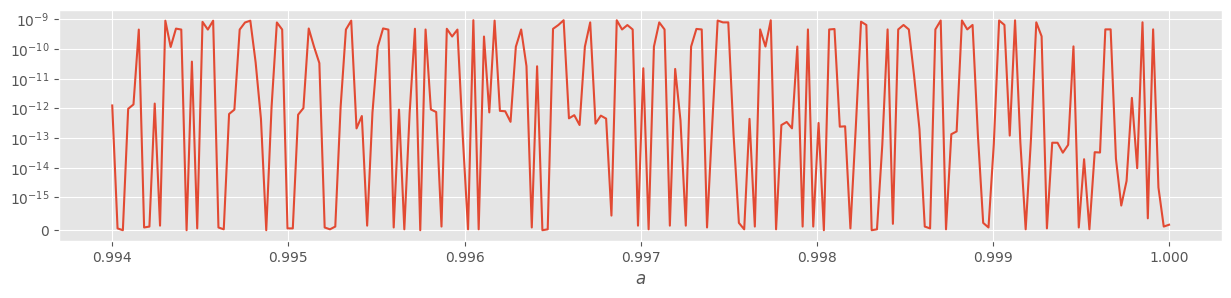

In [34]:
ε  = 6e-3
A = np.linspace(1.0 - ε, 1.0,200)
L_exa = h_1(A,1.0 + A) - h_1(A,1.0 - A)
L_num = np.asarray([quad(lambda r: np.acos( 0.5 * (1.0 - aₙ**2 - r**2)/(aₙ*r) ) * r * np.log(r) * 0.5/np.pi,
                          1-aₙ, 1+aₙ, epsabs=1e-13, epsrel=1e-13)[0] for aₙ in A])
#plt.plot(A, L_exa)
#plt.plot(A, L_num)

plt.figure(figsize=(15,3))
plt.plot(A, abs(L_exa - L_num))
plt.yscale('symlog',linthresh=1e-15)
plt.xlabel(r'$a$')
plt.show()

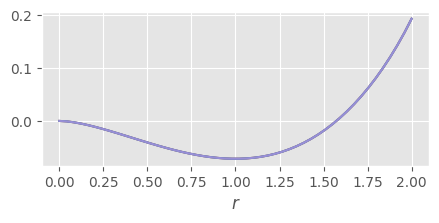

In [35]:
R = np.linspace(1e-14,2)
Ψ = 1.0 - 0.5 * R**2

h_1ra = (0.125 * (R**2 * (2 * np.log(R)-1) *np.acos(-0.5 * R) + h_2(1.0, np.acos(Ψ))) / np.pi)
h_1rn = [quad(lambda r: np.acos( 0.5 * (1.0 - 1.0**2 - r**2)/(1.0*r) ) * r * np.log(r) * 0.5/np.pi,
                          0.0, r, epsabs=1e-13, epsrel=1e-13)[0] for r in R ]
plt.figure(figsize=(5,2))
plt.plot(R,h_1ra)
plt.plot(R,h_1([1.0],R))    # Error around 1e-17
plt.plot(R,h_1rn)           # Error around 1e-16
plt.xlabel(r'$r$')
plt.show()

We observe that the numerical and analytical computations match down to very small errors that can either come from quadrature or from $h_2$. 

---

In [36]:
ε = 1e-5
h_1(1-ε, [np.acos( 0.5 * (1.0 - (1-ε)**2 - ε**2)/( (1-ε) * ε ) )])

array([0.])

In [37]:
h_1(ε, [np.acos( 0.5 * (1.0 - (1-ε)**2 - ε**2)/( (1-ε) * ε ) )])

array([0.])

Recall that we aimed to compute 
\begin{align*}
    H(a) &= \int\limits_0^\varphi \int\limits_0^{s(\theta)} r K(r) \dif r \dif \theta 
    = \color{teal}{ \int\limits_0^\varphi \frac{1}{4(2\pi)} s^2(\theta) \big( \log s^2(\theta) - 1 \big) \dif \theta }
    \\
    &= \int\limits_0^{s(\varphi)} \varphi r K(r) \dif r - \int\limits_{1-a}^{s(\varphi)} \operatorname{arccos}\left( \frac{1-a^2-r^2}{2ar} \right) r K(r) \dif r
    \\
    &=
    \frac{\varphi}{4 (2\pi)} s^2(\varphi) \big( \log s^2(\varphi) - 1\big) - h_1(a)[r]\big|_{1-a}^{s(\varphi)};
\end{align*}
here $s(\theta) = -a \cos(\theta) + \sqrt{ 1 - a^2 \sin^2(\theta) }.$

In what remains of this section, we will contrast the numerical methods to compute $H(a)$ and later we will compute $G(x)$.

In [38]:
# Two numerical solutions
def H_1(a, ε, eps=1e-10):
    """
    Numerically approximates H(a) = (1/2π) ∫_0^φ ∫_0^s(θ) r log(r) dr dθ    for a in (1-ε,1]
    """
    if a <= 1.0 - ε:
        warn("Warning: a is too small. Defaulting to smallest possible value.")
        a = 1.0 - ε + 1e-15
    if abs(1.0-a) < 1e-15:
        # At a = 1.0, the numerical method fails
        a = 1.0 - 1e-15
    
    f = lambda r, θ: r * np.log( r )
    φ = np.acos( 0.5 * (1.0 - a**2 - ε**2)/( a * ε ) )
    
    '''
        Compute approximation
    '''
    s_aε = lambda θ: -a * np.cos(θ) + np.sqrt( 1.0 - a**2 * np.sin(θ)**2 )
    S_aε = lambda θ: 0.25 * s_aε(θ)**2 * (2.0 * np.log(s_aε(θ)) - 1.0)
    
    G  = quad(S_aε, 0, φ, epsabs=eps, epsrel=eps)[0]
    G /= 2.0 * np.pi
    
    return G
def H_2(a, ε, eps=1e-10):
    """
    Numerically approximates H(a) = (1/2π) ∫_0^φ ∫_0^s(θ) r log(r) dr dθ    for a in (1-ε,1]
    """
    if a <= 1.0 - ε:
        warn("Warning: a is too small. Defaulting to smallest possible value.")
        a = 1.0 - ε + 1e-15
    if abs(1.0-a) < 1e-15:
        # At a = 1.0, the numerical method fails
        a = 1.0 - 1e-15
    
    f = lambda r, θ: r * np.log( r )
    φ = np.acos( 0.5 * (1.0 - a**2 - ε**2)/( a * ε ) )
    
    '''
        Compute approximation
    '''
    #s_aε = lambda θ: a * np.cos(θ-np.pi) + np.sqrt( 1.0 - a**2 * np.sin(θ-np.pi)**2 )
    s_aε = lambda θ: -a * np.cos(θ) + np.sqrt( 1.0 - a**2 * np.sin(θ)**2 )
    
    # Since we have an antiderivative of r log(r), we can avoid using a double integral:
    #g_2  = dblquad(f, 0, φ, lambda θ: 0.0, s_aε, epsabs = eps, epsrel = eps)[0]
    
    S_aε = lambda θ: 0.25 * s_aε(θ)**2 * (2.0 * np.log(s_aε(θ)) - 1.0)
    g_2a = quad(lambda r: φ * f(r,0), 0, 1-a)[0]
    g_2b = quad(lambda r: (φ - np.acos( 0.5 * (1-a**2-r**2)/(a*r) ) ) * f(r,0), 1-a, s_aε(φ))[0]
    
    
    '''
        Add terms and correct weights:
    '''
    G = g_2a + g_2b
    G /= 2 * np.pi
    
    return G

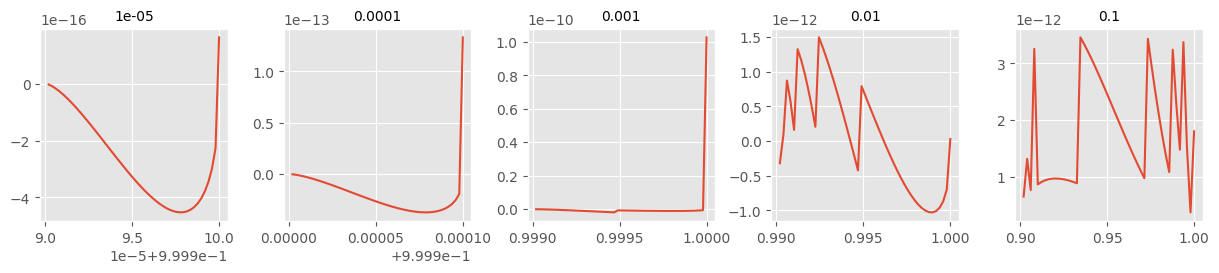

In [39]:
# Compare integrals against each other:
fig, ax = plt.subplots(nrows=1, ncols=5, figsize = (15,2.5))

i = 0
for ε in np.logspace(-5,-1,5):
    A = np.linspace(1.0-ε, 1.0)[1:]
    B = np.asarray([H_1(a, ε, eps=1e-14) for a in A])
    C = np.asarray([H_2(a, ε, eps=1e-14) for a in A])
    ax[i].plot(A, B-C)
    ax[i].set_title(ε, {'fontsize':10})
    i += 1
plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.3, hspace=None)

In [40]:
# Compute exact integral to provide errors
def H_3(a, ε):
    """
    Computes H(a) = (1/2π) ∫_0^φ ∫_0^s(θ) r log(r) dr dθ    for a in (1-ε,1]
    """
    a = np.asarray(a)
    
    if (a < 1.0 - ε).any():
        warn("Warning: a is too small. Defaulting to smallest possible value.")
        np.clip(a, 1.0 - ε, 1.0, a)
    
    ψ = 0.5 * (1.0 - a**2 - ε**2)/( a * ε )
    φ = np.acos( np.clip(ψ, -1.0, 1.0) )
    if (a == 1.0 - ε).any():
        φ[a == 1.0 - ε] = 1.0
    
    '''
        Compute bits
    '''
    s_aε = lambda θ: -a * np.cos(θ) + np.sqrt( 1.0 - a**2 * np.sin(θ)**2 )
    
    g_1 = 0.25 * φ * s_aε(φ)**2 * (2.0 * np.log(s_aε(φ)) - 1.0)
    g_2 = h_1(a, [s_aε(φ)]) - h_1(a, 1.0 - a)
    
    
    '''
        Add terms and correct weights:
    '''
    G = (g_1 * 0.5 /np.pi) - g_2
    
    return G

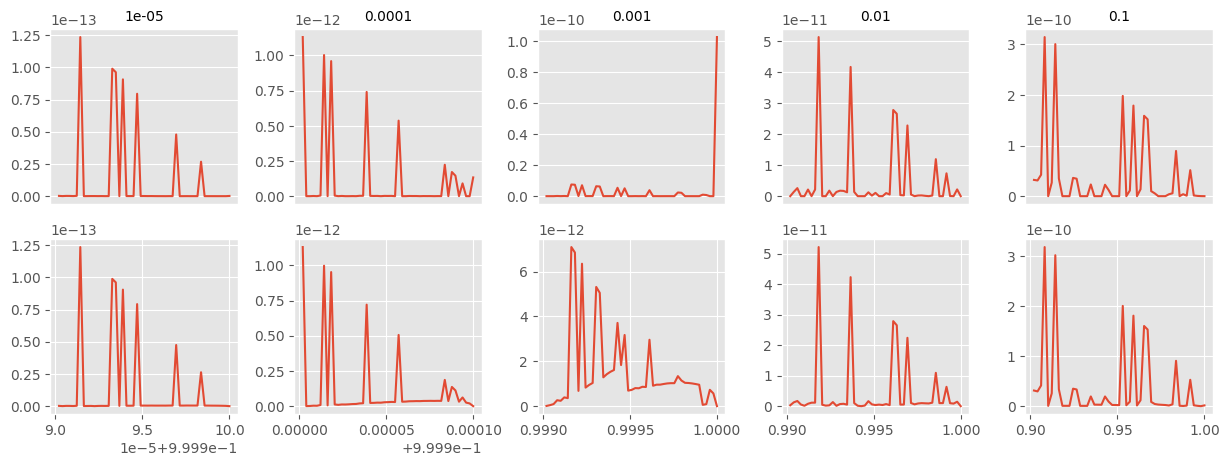

In [41]:
# Compare exact integral against numerical quadrature
fig, ax = plt.subplots(nrows=2, ncols=5, figsize = (15,5) )

i = 0
for ε in np.logspace(-5,-1,5):
    A = np.linspace(1.0-ε, 1.0)[1:]
    B = np.asarray([H_1(a, ε, eps=1e-14) for a in A])
    C = np.asarray([H_2(a, ε, eps=1e-14) for a in A])
    D = H_3(A, ε).ravel()
    
    ax[0,i].plot(A, abs(B-D))
    ax[1,i].plot(A, abs(C-D))
    ax[0,i].set_title(ε, {'fontsize':10})
    ax[0,i].set_xticks([])
    i += 1
plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.3, hspace=None)

The integral decreases very fast:

In [42]:
[H_3( [1.0-ε], ε) for ε in np.logspace(-10,-1,5) ]

[array([[6.41980367e-27]]),
 array([[-6.608658e-16]]),
 array([[-1.59955176e-11]]),
 array([[-3.02655924e-07]]),
 array([[-0.0029901]])]

Finally:
\begin{align*}
    \iint\limits_{◓} K(u) \dif u 
    &= \int\limits_\varphi^\pi \int\limits_0^\varepsilon r K(r) \dif r \dif \theta
    +
    \int\limits_0^\varphi \int\limits_0^{s(\theta)} r K(r) \dif r \dif \theta
    \\
    &= \frac{\pi - \varphi}{8\pi} \varepsilon^2 ( \log \varepsilon^2 - 1) + H(a) = \frac{1}{2}  G(x).
\end{align*}

In [43]:
# Closed formula for convolution
def integral_closed(a, ε):
    """
    Numerically computes G_ε(x) = (1/2π) ∬_{x - ●} log(|x|) dA   for x = (-a,0) and a in (1-ε,1]
    """
    a = np.asarray(a)
    
    if (a < 1.0 - ε).any():
        warn("Warning: a is too small. Defaulting to smallest possible value.")
        np.clip(a, 1.0 - ε, 1.0, a)
    
    # Compute angle of upper intersection
    ψ = 0.5 * (1.0 - a**2 - ε**2)/( a * ε )
    φ = np.acos( np.clip(ψ, -1.0, 1.0) )
    if (a == 1.0 - ε).any():
        φ[a == 1.0 - ε] = 1.0
    
    
    # From radial symmetry, we need only the upper part of the region, then we multiply by 2. 
    # We thus split the upper part into two polar regions
    
    '''
        Compute g_1 = (1/2π) ∫_φ^π ∫_0^ε r log(r) dr dθ (this one is known to be ⅛ (π - φ) ε^2 (log ε^2 - 1) / π
    '''
    g_1 = 0.125 * (np.pi - φ) * ε**2 * (2.0 * np.log(ε) - 1.0) / np.pi
    
    '''
        Compute g_2 = (1/2π) ∫_0^φ ∫_0^s(θ) r log(r) dr dθ = H(a)
    '''

    s_aε = lambda θ: -a * np.cos(θ) + np.sqrt( 1.0 - a**2 * np.sin(θ)**2 )
    
    g_2 = 0.125 * φ * s_aε(φ)**2 * (2.0 * np.log(s_aε(φ)) - 1.0) / np.pi
    g_3 = h_1(a, [s_aε(φ)]) - h_1(a, 1.0 - a)
    
    
    '''
        Add terms and correct weights:
    '''
    G  = g_1 + (g_2 - g_3)
    G *= 2.0
    
    return G

In [44]:
# Compute quadrature without swapping the order of integration
def integral_numeric_b(a, ε, eps=1e-10):
    """
    Numerically approximates G_ε(x) = (1/2π) ∬_{x - ●} log(|x|) dA   for x = (-a,0) and a in (1-ε,1]
    """
    if a <= 1.0 - ε:
        warn("Warning: a is too small. Defaulting to smallest possible value.")
        a = 1.0 - ε + 1e-15
    if abs(1.0-a) < 1e-15:
        # At a = 1.0, the numerical method fails
        a = 1.0 - 1e-15
    
    f = lambda r, θ: r * np.log( r )
    #print(0.5 * (1.0 - a**2 - ε**2)/( a * ε ))
    φ = np.acos( 0.5 * (1.0 - a**2 - ε**2)/( a * ε ) )
    
    # From radial symmetry, we need only the upper part of the region, then we multiply by 2. 
    # We thus split the upper part into two polar regions
    
    '''
        Approximate g_1 = ∫_φ^π ∫_0^ε r log(r) dr dθ (although, this one is known to be 0.25 (π - φ) ε^2 (log ε^2 - 1) 
    '''
    #g_1 = dblquad(f, φ, np.pi, 0, ε, epsabs = eps, epsrel = eps)[0]
    # Personal comment: I truncated the function up to here and tested it against 2 exact_g1(a, ε) yielding an error around 1e-19
    g_1  = exact_g1(a, ε)
    g_1 *= (2 * np.pi)        # Correct integral
    
    '''
        Approximate g_2 = ∫_0^φ ∫_0^s(θ) r log(r) dr dθ 
    '''
    #s_aε = lambda θ: a * np.cos(θ-np.pi) + np.sqrt( 1.0 - a**2 * np.sin(θ-np.pi)**2 )
    s_aε = lambda θ: -a * np.cos(θ) + np.sqrt( 1.0 - a**2 * np.sin(θ)**2 )
    
    # Since we have an antiderivative of r log(r), we can avoid using a double integral:
    #g_2  = dblquad(f, 0, φ, lambda θ: 0.0, s_aε, epsabs = eps, epsrel = eps)[0]
    
    S_aε = lambda θ: 0.25 * s_aε(θ)**2 * (2.0 * np.log(s_aε(θ)) - 1.0)
    g_2a = quad(lambda r: φ * f(r,0), 0, 1-a)[0]
    g_2b = quad(lambda r: (φ - np.acos( 0.5 * (1-a**2-r**2)/(a*r) ) ) * f(r,0), 1-a, s_aε(φ))[0]
    g_2 = g_2a + g_2b
    
    #g_2_o = quad(S_aε, 0, φ, epsabs=eps, epsrel=eps)[0]
    #print(g_2 - g_2_o)
    
    '''
        Add terms and correct weights:
    '''
    #print(φ,g_1/np.pi)
    G  = g_1 + g_2
    G /= np.pi    # 0.5 * 2 = 1.0
    
    return G

In [45]:
B = np.asarray([integral_numeric(a, ε, eps=1e-14) for a in A])
C = np.asarray([integral_numeric_b(a, ε, eps=1e-14) for a in A])

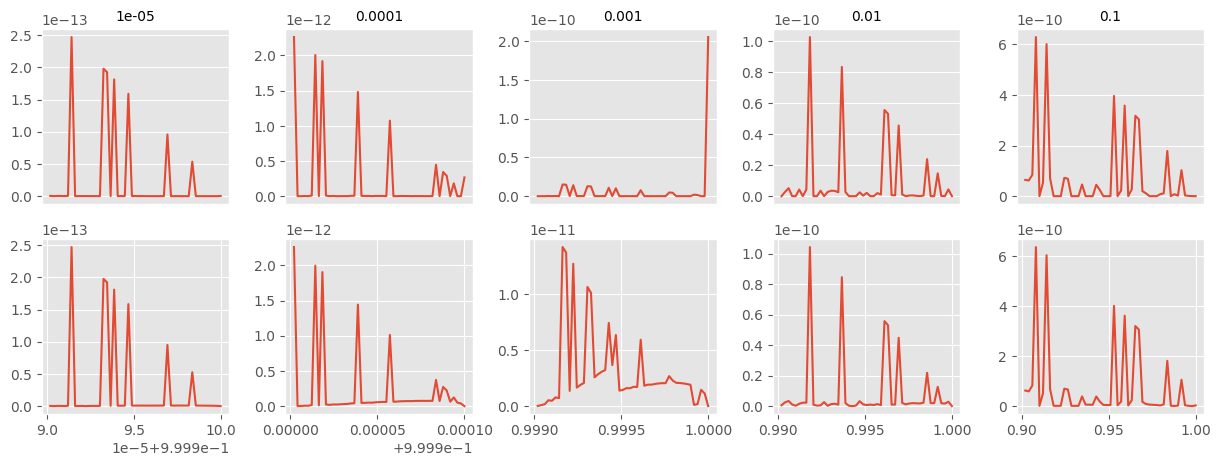

In [46]:
fig, ax = plt.subplots(nrows=2, ncols=5, figsize = (15,5) )

i = 0
for ε in np.logspace(-5,-1,5):
    A = np.linspace(1.0-ε, 1.0)[1:]
    B = np.asarray([integral_numeric(a, ε, eps=1e-14) for a in A])
    C = np.asarray([integral_numeric_b(a, ε, eps=1e-14) for a in A])
    D = integral_closed(A, ε).ravel()
    
    ax[0,i].plot(A, abs(B-D))
    ax[1,i].plot(A, abs(C-D))
    ax[0,i].set_title(ε, {'fontsize':10})
    ax[0,i].set_xticks([])
    i += 1
plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.3, hspace=None)

In [47]:
# Compute convolution in all the domain
def G_closed(a, ε):
    """
    Computes G_ε(x) = (1/2π) ∬_{x - ●} log(|x|) dA for x in (a,0) and a in [0,1]
    """
    x = np.abs(a)
    g = np.zeros_like(x)
    
    g[x <= 1.0 - ε] = 0.25 * ε**2 * (2.0 * np.log(ε) - 1.0)
    g[x >  1.0 - ε] = integral_closed(x[x > 1.0 - ε], ε).ravel()
    
    return g

In [48]:
from matplotlib import rcParams
rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    #"font.serif": ["Computer Modern Roman", "CMU Serif", "DejaVu Serif"],
    "mathtext.fontset": "cm",            # Computer Modern math
    "axes.formatter.use_mathtext": True,
    "axes.unicode_minus": True,
})

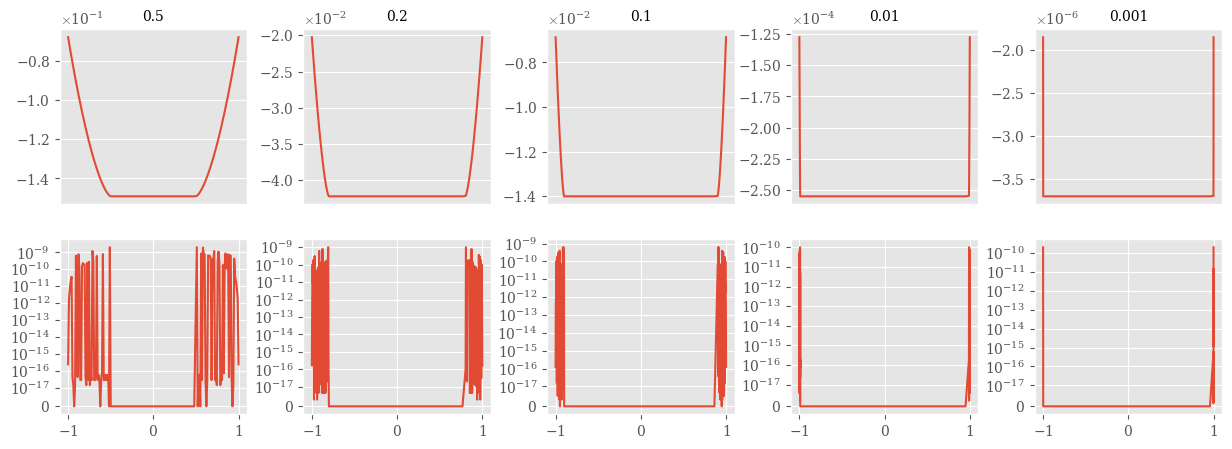

In [49]:
fig, ax = plt.subplots(nrows=2, ncols=5, figsize = (15,5))


i = 0
for ε in [0.5, 0.2, 0.1, 0.01, 0.001]:
    A = np.r_[np.linspace(-1.0, -1.0+ε)[:-1], np.linspace(-1.0+ε, 1.0-ε)[:-1], np.linspace(1.0-ε, 1.0)[1:]]
    B = G_closed(A, ε)
    C = np.asarray([G_num(a, ε, eps=1e-14) for a in A])
    
    ax[0,i].plot(A, B, label = r'$\int_{𝑥−●} K(u) \, \mathrm{d}u$' )
    ax[0,i].set_title(ε, {'fontsize':10})
    ax[0,i].ticklabel_format(axis='both', style='sci', scilimits=(0,0), useMathText=True)
    ax[0,i].set_xticks([])
    
    ax[1,i].plot(A, abs(B-C))
    ax[1,i].set_yscale('symlog', linthresh=1e-17)
    
    i += 1
plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.3, hspace=None)


In [50]:
# Present absolute error against quadrature
for ε in np.logspace(-1,-15,15):
    
    A = np.r_[np.linspace(-1.0, -1.0+ε)[:-1], np.linspace(-1.0+ε, 1.0-ε)[:-1], np.linspace(1.0-ε, 1.0)[1:]]
    
    B = np.asarray([G_num(a, ε, eps=1e-14) for a in A])
    C = G_closed(A, ε)
    
    print('{0:.0e}: {1:.2e}'.format(ε, np.linalg.norm(C-B)))

1e-01: 1.58e-09
1e-02: 2.30e-10
1e-03: 2.95e-10
1e-04: 5.77e-12
1e-05: 6.44e-13
1e-06: 6.34e-14
1e-07: 8.86e-15
1e-08: 1.11e-15
1e-09: 1.24e-17
1e-10: 1.37e-19
1e-11: 1.50e-21
1e-12: 1.64e-23
1e-13: 1.77e-25
1e-14: 1.92e-27
1e-15: 6.03e-29


---

Thus, we have the following final expression where $● :=B_2(x;\varepsilon) \cap B_2(0;1)$:
\begin{align*}
    G_\varepsilon (x) &= \frac{1}{2\pi} \int\limits_{ x - ● } \log |y| \,\mathrm{d}y
    =
    \begin{cases}
        \dfrac{\varepsilon^2}{4}(\log \varepsilon^2 - 1) & \text{if } x \in \overline{B}(0;1-\varepsilon),
        \\
        F_\varepsilon (x)  & \text{if } \mathrm{d}\big(x, \partial B(0;1) \big) \in [0,1-\varepsilon),
    \end{cases}
\end{align*}
To compute the second case, let $\varphi = \arccos \left( \dfrac{1 - |x|^2 - \varepsilon^2}{2|x|\varepsilon} \right)$ and $s = -|x| \cos\varphi + \sqrt{ 1 - |x|^2 \sin^2 \varphi }$, then
\begin{align*}
    F_\varepsilon (x) 
    &= \frac{\pi - \varphi}{4\pi} \varepsilon^2 ( \log \varepsilon^2 - 1) + 2 H( |x| )
    \\
    &= \frac{1}{4\pi} \left[ (\pi - \varphi) \varepsilon^2 ( \log \varepsilon^2 - 1) + \varphi \, s^2 \big( \log s^2 - 1\big) -  h_1(x;r) \big|_{1-a}^{s}  \right]
    \\
    h_1(x; r) 
    &= r^2 (\log r^2 -1) \operatorname{arccos} \left( \dfrac{1-|x|^2-r^2}{2|x|r} \right) +  h_2\big(x, \phi(x;r) \big),
    \\
    h_2(x; \phi) 
    &= 
    2 \Im \big( \mathrm{Li}_2 ( |x| e^{i \phi} ) \big)
        + (1-|x|^2)\left[ \phi + \arctan\left(\frac{|x|\sin\phi}{1-|x|\cos\phi}\right)\right] + |x|\big( \log(1-2|x|\cos\phi+|x|^2) - 2 \big)\sin\phi ;
\end{align*}
and finally $\phi(x;r) = \arccos \left(\dfrac{1 + |x|^2 - r^2}{2|x|} \right)$.

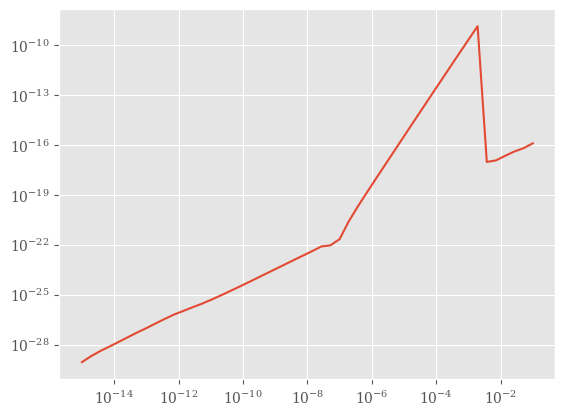

In [51]:
# Display error against numerical quadrature at a = 1
E = np.logspace(-15,-1)
C = np.asarray([G_num(1.0, ε, eps=1e-14) for ε in E])
plt.plot(E, abs(C - np.asarray([integral_closed([1.0], ε).ravel() for ε in E]).ravel()) )
plt.xscale('log')
plt.yscale('log')

# Plot region when $a \in (1-\varepsilon,1]$

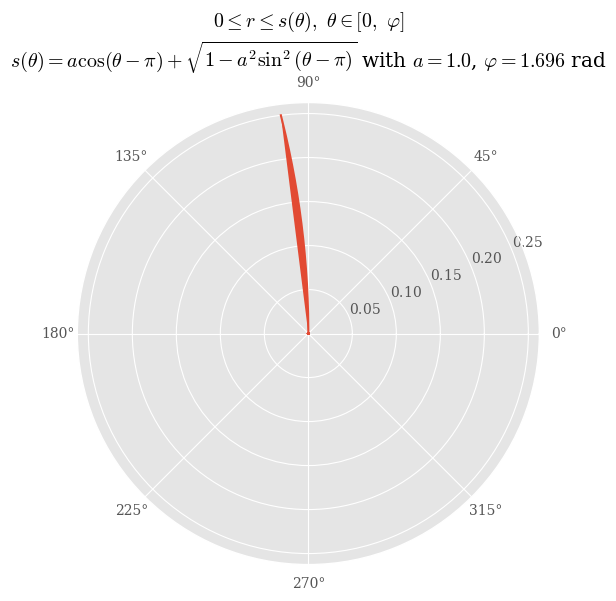

In [52]:
# Plot the tricky area
ε = 0.25
a = 1.0 #-ε + 1e-5
φ = np.acos( 0.5 * (1.0 - a**2 - ε**2)/( a * ε ) )

# ---- Definition of s(θ) ----
def s(θ, a, φ):
    s_θ = -a * np.cos(θ) + np.sqrt( 1.0 - a**2 * np.sin(θ)**2 )
    return s_θ

# ---- Sample θ and compute r ----
θ = np.linspace(0.0, φ, 1000)
r = s(θ, a, φ)

# ---- Plot on polar axes ----
fig, ax = plt.subplots(subplot_kw={'projection': 'polar'}, figsize=(6, 6))

# Fill the region 0 ≤ r ≤ s(θ) for θ ∈ [0, φ]
ax.fill_between(θ, 0.0, r)

# Plot the boundary curve r = s(θ) on top
ax.plot(θ, r)

# Aesthetics
ax.set_title(
    r"$0 \leq r \leq s(\theta),\ \theta \in [0,\ \varphi]$"
    + "\n"
    + rf"$s(\theta) = a\cos(\theta-\pi) + \sqrt{{1 - a^2\sin^2(\theta-\pi)}}$"
    + rf" with $a={a}$, $\varphi={φ:.3f}$ rad"
)
plt.show()

---